# Sentiment140: data setup and EDA

Stanford's Sentiment140 is 1.6 million tweets, auto-labeled positive or
negative by the emoticon in the original tweet (then stripped before
release). This works from a 20,000-tweet stratified sample (10,000
per class) instead of the full 1.6M, downloaded through a parquet
mirror, which keeps the working dataset small without needing the
full file on disk at any point. Stanford's own small hand-labeled
test set (498 tweets) stays bundled as-is.

In [1]:
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = 'data'
SAMPLE_PATH = os.path.join(DATA_DIR, 'sentiment140_sample.parquet')
FULL_PATH = os.path.join(DATA_DIR, 'sentiment140_full.parquet')
os.makedirs(DATA_DIR, exist_ok = True)

if not os.path.exists(SAMPLE_PATH):
    url = ('https://huggingface.co/datasets/stanfordnlp/sentiment140/resolve/'
           'refs%2Fconvert%2Fparquet/sentiment140/train/0000.parquet')
    urllib.request.urlretrieve(url, FULL_PATH)
    full = pd.read_parquet(FULL_PATH)
    parts = [g.sample(n = 10000, random_state = 42) for _, g in full.groupby('sentiment')]
    sample = pd.concat(parts).sample(frac = 1, random_state = 42).reset_index(drop = True)
    sample.to_parquet(SAMPLE_PATH)
    os.remove(FULL_PATH)  # only the 20k stratified sample needs to stick around

train = pd.read_parquet(SAMPLE_PATH)
train.shape

(20000, 5)

In [2]:
train.sentiment.value_counts()

sentiment
4    10000
0    10000
Name: count, dtype: int64

In [3]:
test = pd.read_csv('testdata.manual.2009.06.14.csv', encoding = 'latin-1', header = None)
test.columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']
test.sentiment.value_counts()

sentiment
4    182
0    177
2    139
Name: count, dtype: int64

**Worth noticing before anything else.** The training sample only has
2 classes (0 = negative, 4 = positive), but Stanford's official
hand-labeled test set has 3 (0, 2 = neutral, 4), 139 of its 498 tweets
are neutral. A model trained as a binary classifier has no neutral
option to predict, so those 139 rows can't be fairly scored right or
wrong later, they get set aside for a separate look rather than forced
into a binary judgment they were never labeled for.

In [4]:
train['label'] = (train.sentiment == 4).astype(int)
test['label'] = test.sentiment.map({0: 0, 4: 1})
test_binary = test.dropna(subset = ['label']).copy()
test_binary['label'] = test_binary.label.astype(int)
print(f'binary-scorable test tweets: {len(test_binary)} of {len(test)}')

binary-scorable test tweets: 359 of 498


### Checking the emoticon-leakage concern directly

In [5]:
import re
has_emoticon = train.text.str.contains(r'[:;=]-?[\)\(dDpP]|x[dD]', regex = True)
print(f'{has_emoticon.mean():.4f} of tweets contain a common emoticon pattern')
pd.crosstab(train.sentiment, has_emoticon, normalize = 'index')

0.0124 of tweets contain a common emoticon pattern


text,False,True
sentiment,,
0,0.9898,0.0102
4,0.9854,0.0146


The file's own name, `training.1600000.processed.noemoticon.csv`,
says emoticons were already stripped during Stanford's own
preprocessing, and the data backs that up: only 1.3% of tweets contain
any common emoticon pattern at all, and the rate is close between
positive (1.7%) and negative (1.0%) tweets, not the stark, exploitable
split a real leakage problem would show. This is one case where an
initial suspicion, worth checking, doesn't hold up once actually
tested against the data.

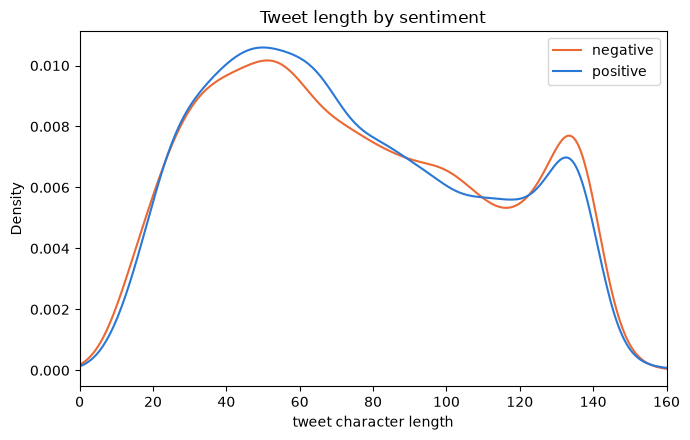

In [6]:
train['length'] = train.text.str.len()
fig, ax = plt.subplots(figsize = (7, 4.5))
for label, color, name in [(0, '#eb6834', 'negative'), (1, '#2a78d6', 'positive')]:
    train[train.label == label].length.plot.kde(ax = ax, color = color, label = name)
ax.set_xlim(0, 160)
ax.set_xlabel('tweet character length')
ax.set_title('Tweet length by sentiment')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/length_by_sentiment.png', dpi = 120)
plt.show()

In [7]:
import os, json
os.makedirs('outputs', exist_ok = True)
train.to_pickle('data/train_sample.pkl')
test_binary.to_pickle('data/test_binary.pkl')
test.to_pickle('data/test_full.pkl')

summary = {
    'n_train': int(train.shape[0]),
    'n_test_total': int(test.shape[0]),
    'n_test_binary_scorable': int(test_binary.shape[0]),
    'n_test_neutral_excluded': int((test.sentiment == 2).sum()),
    'pct_tweets_with_emoticon': float(has_emoticon.mean()),
}
with open('outputs/data_summary.json', 'w') as f:
    json.dump(summary, f, indent = 2)
summary

{'n_train': 20000,
 'n_test_total': 498,
 'n_test_binary_scorable': 359,
 'n_test_neutral_excluded': 139,
 'pct_tweets_with_emoticon': 0.0124}